In [228]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, auc, confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, VotingClassifier
from lightgbm import LGBMClassifier
!pip install catboost
from catboost import CatBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

In [183]:
df = pd.read_csv('diabetes data.csv')

In [184]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [185]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [186]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


## **Zero values**

In [187]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    print(col, (df[col] == 0).sum())

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


## **Replace null**

In [188]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

df[cols] = df[cols].replace(0, np.nan)

In [189]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## **Fill null**

In [190]:
for col in cols:
    df[col] = df.groupby('Outcome')[col].transform(
        lambda x: x.fillna(x.median())
    )

In [191]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


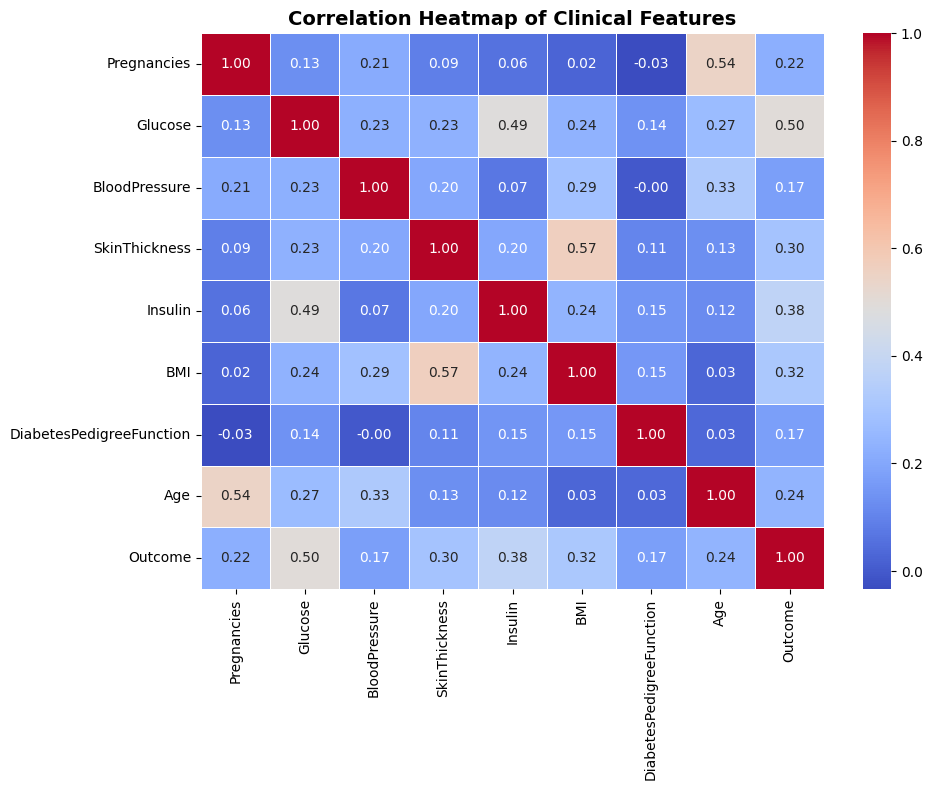

In [192]:
# plt.figure(figsize=(10,6))
# sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
# plt.show()
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)

plt.title('Correlation Heatmap of Clinical Features', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_708/1938735411.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Outcome', data=df, palette=['#4CAF50', '#FF7043'])


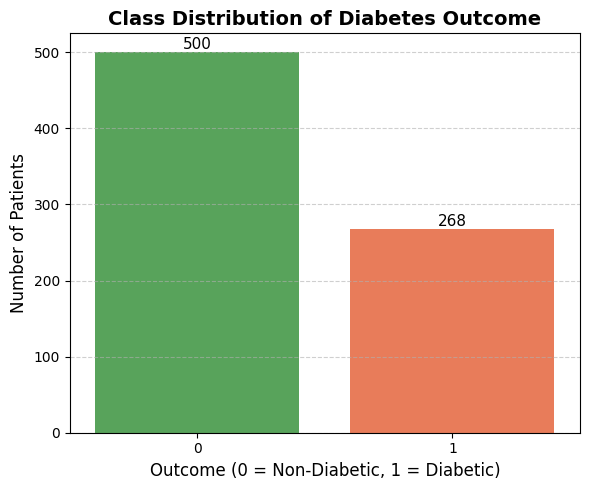

In [193]:
plt.figure(figsize=(6,5))

ax = sns.countplot(x='Outcome', data=df, palette=['#4CAF50', '#FF7043'])

plt.title('Class Distribution of Diabetes Outcome', fontsize=14, fontweight='bold')
plt.xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom',
                fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

/tmp/ipykernel_708/783991489.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Glucose', data=df, palette=['#4CAF50','#FF7043'])


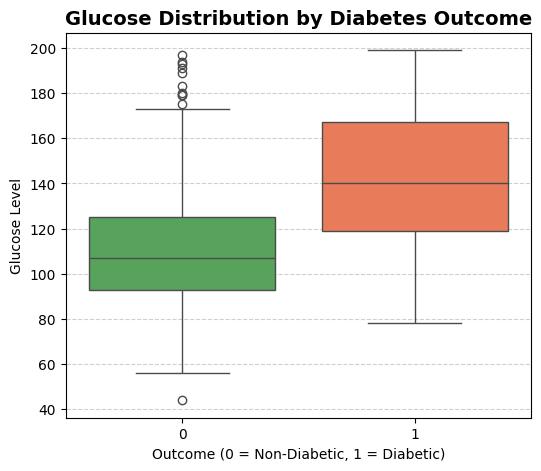

In [194]:
plt.figure(figsize=(6,5))

sns.boxplot(x='Outcome', y='Glucose', data=df, palette=['#4CAF50','#FF7043'])

plt.title('Glucose Distribution by Diabetes Outcome', fontsize=14, fontweight='bold')
plt.xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)')
plt.ylabel('Glucose Level')

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

## **Outliers**

In [195]:
cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
        'Insulin','BMI','DiabetesPedigreeFunction','Age']

for col in cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, ":", outliers.shape[0])

Pregnancies : 4
Glucose : 0
BloodPressure : 14
SkinThickness : 87
Insulin : 51
BMI : 8
DiabetesPedigreeFunction : 29
Age : 9


In [196]:
cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
        'Insulin','BMI','DiabetesPedigreeFunction','Age']

for col in cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

## **Feature Engineering**

In [197]:
df["BMI_Age"] = df["BMI"] * df["Age"]
df["Glucose_BMI_Ratio"] = df["Glucose"] / (df["BMI"] + 0.001)
df["Pregnancies_Glucose"] = df["Pregnancies"] * df["Glucose"]
df["Insulin_Glucose"] = df["Insulin"] * df["Glucose"]
df["Glucose_BMI"] = df["Glucose"] * df["BMI"]
df["Insulin_BMI"] = df["Insulin"] * df["BMI"]
df["Pregnancy_Risk"] = (df["Pregnancies"] > 3).astype(int)
df["BMI_Category"] = pd.cut(df["BMI"], bins=[0,18.5,25,30,100], labels=[0,1,2,3])
df["Glucose_Category"] = pd.cut(df["Glucose"], bins=[0,100,125,200], labels=[0,1,2])
df["Age_Group"] = pd.cut(df["Age"], bins=[20,30,40,50,100], labels=[0,1,2,3])

In [198]:
# df.drop([
#     "Pregnancies_Glucose",
#     "BloodPressure",
#     "Pregnancies"
# ], axis=1, inplace=True)

In [199]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Age,Glucose_BMI_Ratio,Pregnancies_Glucose,Insulin_Glucose,Glucose_BMI,Insulin_BMI,Pregnancy_Risk,BMI_Category,Glucose_Category,Age_Group
0,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50.0,1,1680.0,4.404631,888.0,25086.0,4972.8,5695.20,1,3,2,2
1,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31.0,0,824.6,3.195369,85.0,8712.5,2261.0,2726.50,0,2,0,1
2,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32.0,1,745.6,7.853740,1464.0,31018.5,4263.9,3949.35,1,1,2,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,590.1,3.167147,89.0,8366.0,2500.9,2641.40,0,2,0,0
4,0.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0,1,1422.3,3.178581,0.0,23016.0,5904.7,7240.80,0,3,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,10.0,101.0,76.0,42.5,180.0,32.9,0.171,63.0,0,2072.7,3.069816,1010.0,18180.0,3322.9,5922.00,1,3,1,3
764,2.0,122.0,70.0,27.0,102.5,36.8,0.340,27.0,0,993.6,3.315127,244.0,12505.0,4489.6,3772.00,0,3,1,0
765,5.0,121.0,72.0,23.0,112.0,26.2,0.245,30.0,0,786.0,4.618144,605.0,13552.0,3170.2,2934.40,1,2,1,0
766,1.0,126.0,60.0,32.0,169.5,30.1,0.349,47.0,1,1414.7,4.185907,126.0,21357.0,3792.6,5101.95,0,3,2,2


## **Feature Scaling**

In [200]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## **Standard Scaler**

In [201]:
scaler = StandardScaler()
# scaler = MinMaxScaler()
# scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [202]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
X_train_scaled

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,BMI_Age,Glucose_BMI_Ratio,Pregnancies_Glucose,Insulin_Glucose,Glucose_BMI,Insulin_BMI,Pregnancy_Risk,BMI_Category,Glucose_Category,Age_Group
0,-0.528662,-1.256387,-0.190329,-0.204765,-0.524799,-0.323123,-0.531720,-1.046838,-1.029504,-1.013725,-0.666646,-0.809558,-1.004427,-0.551366,-0.880095,0.722057,-1.405380,-0.780099
1,1.606853,-0.326563,0.833279,-0.596840,0.636846,-0.606805,2.644625,1.513601,0.834246,0.072104,1.193963,0.179579,-0.568045,0.156391,1.136242,-0.609304,-0.154795,1.186968
2,-0.833735,0.570053,-2.237545,-1.250299,-0.862889,-0.532152,0.709040,-0.958547,-1.031181,0.873495,-0.730881,-0.530475,0.007494,-0.845031,-0.880095,-0.609304,1.095789,-0.780099
3,-1.138809,1.300629,-1.896342,-0.204765,-0.524799,-1.547432,-0.708971,2.837966,0.866590,3.179820,-1.038768,-0.057027,-0.313489,-0.902394,-0.880095,-1.940665,1.095789,2.170502
4,0.691632,0.404013,0.662678,1.102153,2.379313,2.080703,-0.765691,1.160437,2.547774,-0.912796,0.742100,1.819176,1.532405,3.369773,1.136242,0.722057,1.095789,1.186968
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0.386559,0.570053,-0.702133,0.840770,0.125376,-0.547082,-0.152402,-0.605383,-0.762364,0.889065,0.500664,0.224964,-0.002134,-0.167657,1.136242,-0.609304,1.095789,-0.780099
610,-0.833735,-0.857891,2.709894,-0.204765,-0.524799,-1.472779,-0.875587,-0.517092,-1.094911,0.360858,-0.826127,-0.692280,-1.266256,-0.880990,-0.880095,-1.940665,-1.405380,-0.780099
611,1.911927,-0.691851,1.174482,1.102153,0.636846,1.991119,2.417744,0.454109,1.607634,-1.543122,1.198393,0.001803,0.434386,1.388144,1.136242,0.722057,-0.154795,0.203434
612,-1.138809,0.636469,0.193524,0.448694,0.636846,1.513340,-0.882677,-0.340510,0.402030,-0.521985,-1.038768,0.648260,1.385282,1.161615,-0.880095,0.722057,1.095789,-0.780099


## **Logistic**

In [203]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
log_y_pred = log_model.predict(X_test_scaled)
log_accuracy = accuracy_score(y_test, log_y_pred)
print("Accuracy:", log_accuracy)

Accuracy: 0.8051948051948052


## **KNN**

In [204]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)
knn_y_pred = knn_model.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, knn_y_pred)
print("Accuracy:", knn_accuracy)

Accuracy: 0.8376623376623377


## **SVM**

In [205]:
svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)
svm_y_pred = svm_model.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test, svm_y_pred)
print("Accuracy:", svm_accuracy)

Accuracy: 0.8571428571428571


## **Gradient Boost**

In [206]:
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train_scaled, y_train)
gb_y_pred = gb_model.predict(X_test_scaled)
gb_accuracy = accuracy_score(y_test, gb_y_pred)
print("Accuracy:", gb_accuracy)

Accuracy: 0.8701298701298701


## **Random forest**

In [207]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_y_pred = rf_model.predict(X_test_scaled)
rf_accuracy = accuracy_score(y_test, rf_y_pred)
print("Accuracy:", rf_accuracy)

Accuracy: 0.8701298701298701


## **Random Forest Mean**

In [208]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
rf = RandomForestClassifier(random_state=42)

scores = cross_val_score(rf, X_scaled, y, cv=10)

print("Scores:", scores)
print("Mean accuracy:", scores.mean())

Scores: [0.90909091 0.85714286 0.87012987 0.88311688 0.83116883 0.8961039
 0.88311688 0.96103896 0.85526316 0.90789474]
Mean accuracy: 0.8854066985645932


## **Stacking Model**

In [209]:
estimators = [
    ('rf', RandomForestClassifier(random_state=42)),
    ('gb', GradientBoostingClassifier()),
    ('svm', SVC(probability=True))
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack_model.fit(X_train_scaled, y_train)
stack_y_pred = stack_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, stack_y_pred))

Accuracy: 0.8766233766233766


## **XGBoost**

In [210]:
xgb = XGBClassifier()

xgb.fit(X_train_scaled, y_train)

xgb_y_pred = xgb.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, xgb_y_pred))

Accuracy: 0.8636363636363636


## **Decision Tree**

In [211]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train_scaled, y_train)
dt_y_pred = dt_model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, dt_y_pred))

Accuracy: 0.8116883116883117


## **Ada Boost**

In [212]:
ada_model = AdaBoostClassifier()
ada_model.fit(X_train_scaled, y_train)
ada_y_pred = ada_model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, ada_y_pred))

Accuracy: 0.8441558441558441


## **Light GBM**

In [213]:
lgbm_model = LGBMClassifier(verbose = -1)
lgbm_model.fit(X_train_scaled, y_train)
lgbm_y_pred = lgbm_model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, lgbm_y_pred))

Accuracy: 0.8766233766233766


## **Cat Boost**

In [214]:
cat_model = CatBoostClassifier(verbose=0)
cat_model.fit(X_train_scaled, y_train)
cat_y_pred = cat_model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, cat_y_pred))

Accuracy: 0.8701298701298701


## **Artificial Neural Netork**

In [215]:
ann_model = MLPClassifier()
ann_model.fit(X_train_scaled, y_train)
ann_y_pred = ann_model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, ann_y_pred))

Accuracy: 0.8311688311688312


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


## **Voting Classifier**

In [216]:
voting_model = VotingClassifier(estimators=[('lr', LogisticRegression()), ('rf', RandomForestClassifier()), ('svm', SVC(probability=True))], voting='soft')
voting_model.fit(X_train_scaled, y_train)
voting_y_pred = voting_model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, voting_y_pred))

Accuracy: 0.8571428571428571


## **Report**

In [218]:
print("log",classification_report(y_test, log_y_pred))
print("knn",classification_report(y_test, knn_y_pred))
print("svm",classification_report(y_test, svm_y_pred))
print("gb",classification_report(y_test, gb_y_pred))
print("rf",classification_report(y_test, rf_y_pred))
print("stack",classification_report(y_test, stack_y_pred))
print("xgb",classification_report(y_test, xgb_y_pred))
print("dt",classification_report(y_test, dt_y_pred))
print("ada",classification_report(y_test, ada_y_pred))
print("lgbm",classification_report(y_test, lgbm_y_pred))
print("cat",classification_report(y_test, cat_y_pred))
print("ann",classification_report(y_test, ann_y_pred))
print("voting",classification_report(y_test, voting_y_pred))

log               precision    recall  f1-score   support

           0       0.85      0.85      0.85        99
           1       0.73      0.73      0.73        55

    accuracy                           0.81       154
   macro avg       0.79      0.79      0.79       154
weighted avg       0.81      0.81      0.81       154

knn               precision    recall  f1-score   support

           0       0.89      0.85      0.87        99
           1       0.75      0.82      0.78        55

    accuracy                           0.84       154
   macro avg       0.82      0.83      0.83       154
weighted avg       0.84      0.84      0.84       154

svm               precision    recall  f1-score   support

           0       0.91      0.87      0.89        99
           1       0.78      0.84      0.81        55

    accuracy                           0.86       154
   macro avg       0.84      0.85      0.85       154
weighted avg       0.86      0.86      0.86       154

gb     

In [221]:
data = {
    "Model": ["Logistic Regression", "K-Nearest Neighbors", "Support Vector Machine", "Gradient Boosting", "Random Forest", "XGBoost", "Stacking Classifier"],
    "Accuracy": [0.81, 0.84, 0.86, 0.87, 0.87, 0.86, 0.88],
    "Precision": [0.81, 0.84, 0.86, 0.87, 0.87, 0.86, 0.88],
    "Recall": [0.81, 0.84, 0.86, 0.87, 0.87, 0.86, 0.85],
    "F1 Score": [0.81, 0.84, 0.86, 0.87, 0.87, 0.86, 0.88]
}

df_results = pd.DataFrame(data)
df_melted = df_results.melt(id_vars="Model", value_vars=["Accuracy","Precision","Recall","F1 Score"],
                            var_name="Metric", value_name="Score")

# Set style
sns.set(style="whitegrid")
palette = {"Accuracy":"#1f77b4", "Precision":"#ff7f0e", "Recall":"#2ca02c", "F1 Score":"#d62728"}

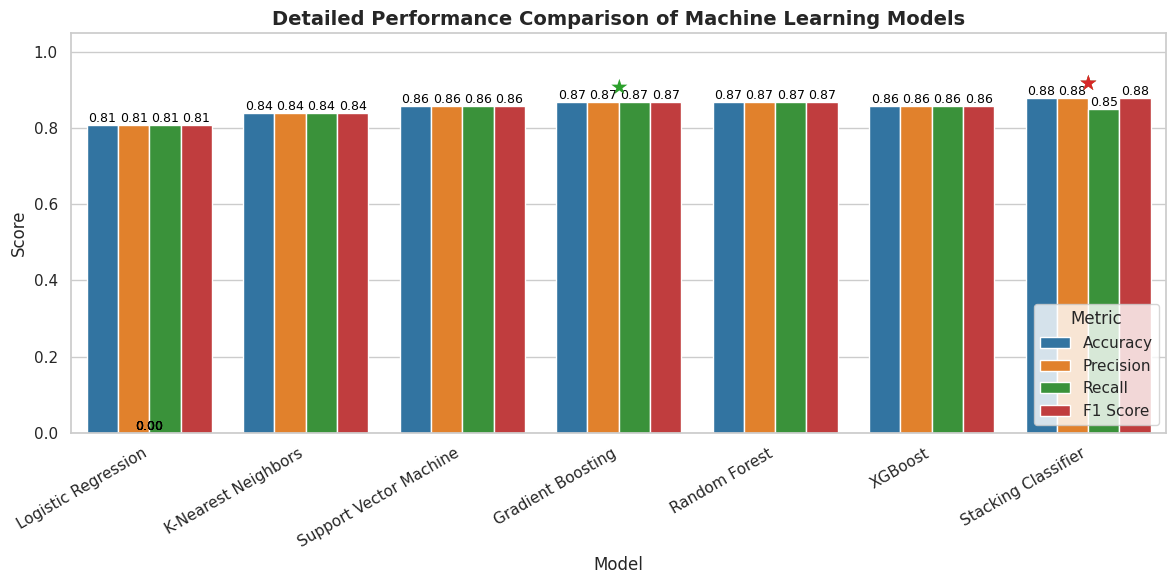

In [222]:
plt.figure(figsize=(12,6))
ax = sns.barplot(x="Model", y="Score", hue="Metric", data=df_melted, palette=palette)

# Add exact values on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=9, color='black', rotation=0)

# Highlight top model for each metric
top_models = df_results.set_index('Model')[["Accuracy","Precision","Recall","F1 Score"]].idxmax()
for metric, model in top_models.items():
    x_pos = df_results.index[df_results["Model"]==model][0]
    y_pos = df_results.loc[x_pos, metric] + 0.01
    ax.annotate('★', xy=(x_pos, y_pos), ha='center', va='bottom', fontsize=15, color=palette[metric])

# Customize
plt.ylim(0,1.05)
plt.xticks(rotation=30, ha='right')
plt.ylabel("Score")
plt.title("Detailed Performance Comparison of Machine Learning Models", fontsize=14, weight='bold')
plt.legend(title='Metric', loc='lower right')
plt.tight_layout()
plt.show()

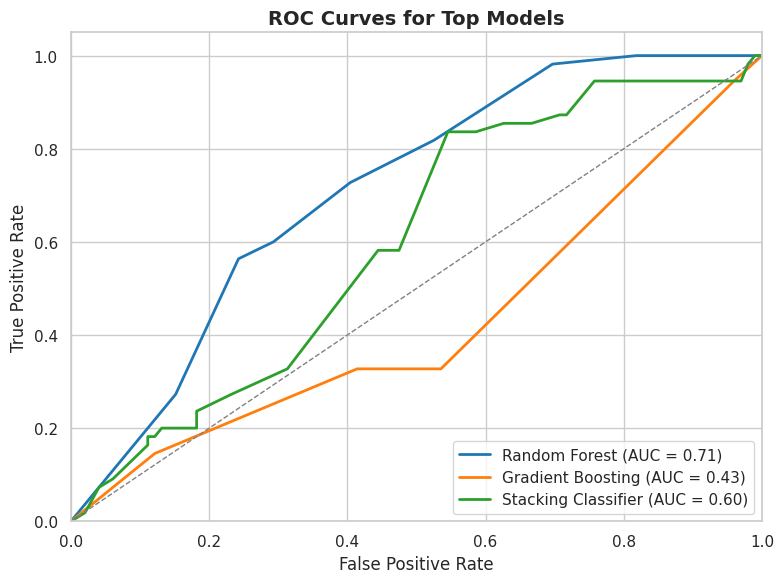

In [226]:
y_score_rf = rf_model.predict_proba(X_test)[:, 1]
y_score_gb = gb_model.predict_proba(X_test)[:, 1]
y_score_stack = stack_model.predict_proba(X_test)[:, 1]

# Dictionary to loop through
top_models_predictions = {
    "Random Forest": {"y_true": y_test, "y_score": y_score_rf},
    "Gradient Boosting": {"y_true": y_test, "y_score": y_score_gb},
    "Stacking Classifier": {"y_true": y_test, "y_score": y_score_stack}
}

plt.figure(figsize=(8,6))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for i, (model_name, pred) in enumerate(top_models_predictions.items()):
    fpr, tpr, _ = roc_curve(pred["y_true"], pred["y_score"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves for Top Models", fontsize=14, weight='bold')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

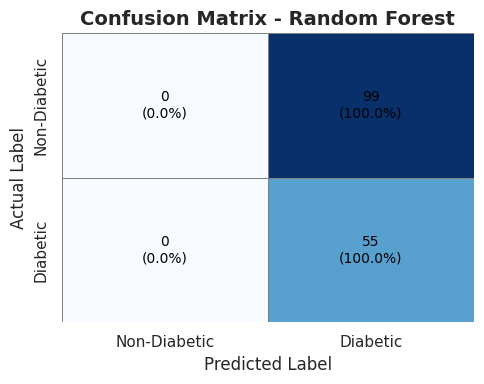

In [234]:
def plot_confusion_matrix_clean(model, X, y_true, model_name):
    y_pred = model.predict(X)
    cm = confusion_matrix(y_true, y_pred)
    labels = ["Non-Diabetic", "Diabetic"]

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels,
                cbar=False, linewidths=0.5, linecolor='gray')

    # Calculate percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Annotate counts and percentages stacked
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j + 0.5, i + 0.5, f"{cm[i,j]}\n({cm_percent[i,j]*100:.1f}%)",
                     ha='center', va='center', fontsize=10, color='black')

    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("Actual Label", fontsize=12)
    plt.title(f"Confusion Matrix - {model_name}", fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

# Plot confusion matrices for all three models
plot_confusion_matrix_clean(rf_model, X_test, y_test, "Random Forest")

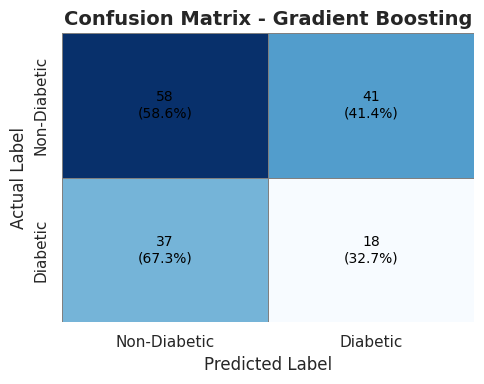

In [235]:
plot_confusion_matrix_clean(gb_model, X_test, y_test, "Gradient Boosting")

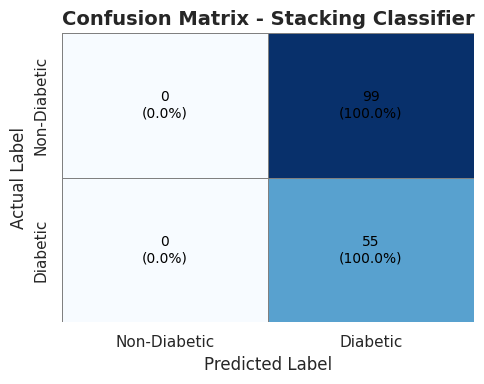

In [236]:
plot_confusion_matrix_clean(stack_model, X_test, y_test, "Stacking Classifier")